# Generate Melt Dates Using ERA5-Land Variables

This code derives melt onset date (MOD) and melt end date (MED) from ERA5-Land variables (air temperature and SWE) for intercomparison.

The same rule-based procedure used for the in situ data is applied here (see `Figure11b_Generate_MeltDates_From_Insitu_Data.ipynb` for details).

Quality control (QC) is applied to remove unreliable cases:

- Remove early detections (MOD < DOY 30)  
- Remove cases with ≥ 10 zero-SWE days within DOY 1–30  
- Remove cases with annual maximum SWE ≤ 50 mm  

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Define functions to plot for the north of 60°N

In [2]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## Create the land mask for regions north of 60°N

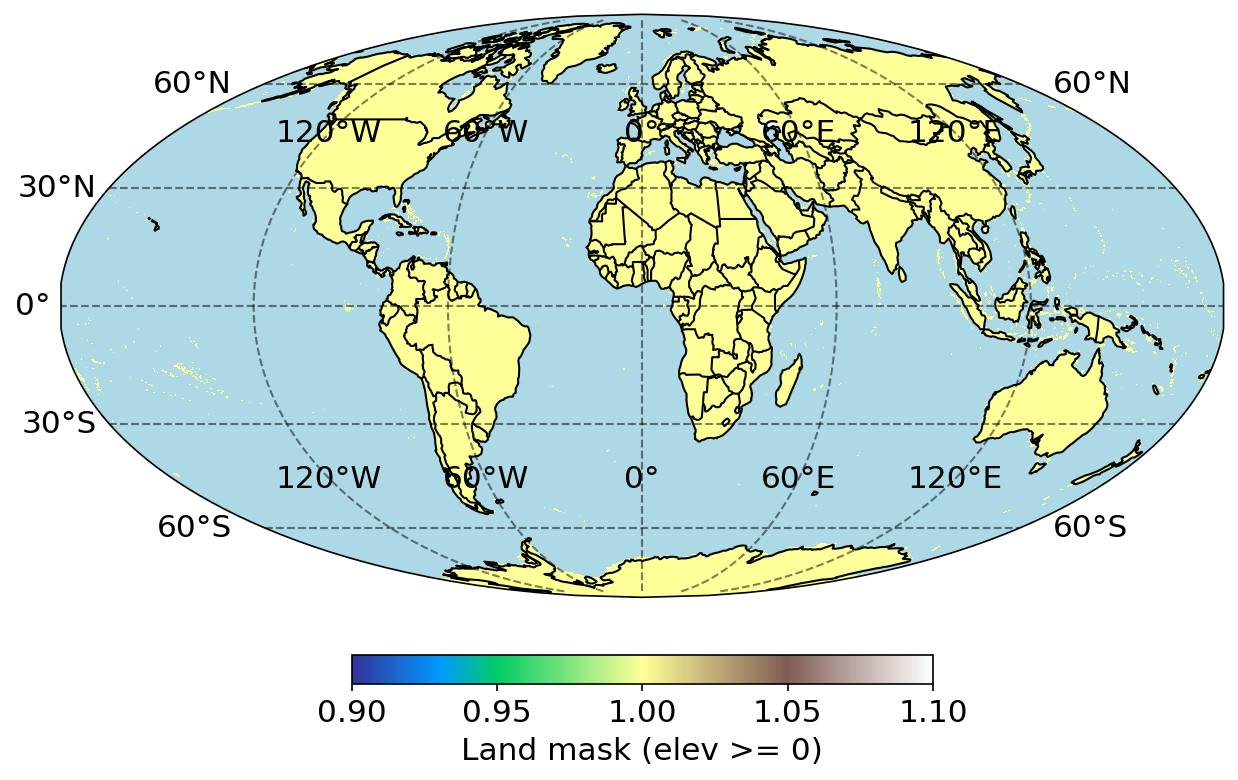

In [3]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Calculate MOD from ERA5-Land SWE and Tair
This code calculates melt onset date (MOD) from ERA5-Land snow water equivalent (SWE) and air temperature (Tair).
MOD is defined as the first day of a 3-day window where:
- 3-day mean Tair > 3°C
- SWE is strictly decreasing over the 3 days
- SWE is positive for all 3 days

Quality control (QC) is applied to remove unreliable cases:
- Annual maximum SWE ≤ 50 mm
- ≥ 10 zero-SWE days within DOY 1–30
- MOD < DOY 30

This function returns a 2D MOD map (DOY), with invalid pixels set to NaN.

In [4]:
def get_ERA5_MOD(
    SWE_new, T_air_new,
    *,
    early_thr=30,
    zero_window=30,
    zero_thr=10,
    SWE_max_thr=50.0,
    tair_thr=3.0,
    doy_start=1,
    return_qc_masks=False,
):

    # 1. Check the input data
    SWE = np.asarray(SWE_new, dtype=float)
    Tair = np.asarray(T_air_new, dtype=float)

    if SWE.ndim != 3 or Tair.ndim != 3: # (lat, lon, days)
        raise ValueError(f"SWE_new and T_air_new must be 3D (H,W,N). Got SWE {SWE.shape}, Tair {Tair.shape}")
    if SWE.shape != Tair.shape:
        raise ValueError(f"SWE_new and T_air_new must have same shape. Got {SWE.shape} vs {Tair.shape}")

    H, W, N = SWE.shape
    if N < 3:
        out = np.full((H, W), np.nan, dtype=np.float32)
        return (out, {}) if return_qc_masks else out


    # 2. Create Quality Control masks
    # QC1: Annual max SWE <= threshold
    swe_max = np.nanmax(SWE, axis=2)
    qc_low_peak = np.isfinite(swe_max) & (swe_max <= SWE_max_thr)

    # QC2: Too many zero/negative SWE days in early season
    n0 = min(zero_window, N)
    zero_days = np.sum((SWE[:, :, :n0] <= 0) & np.isfinite(SWE[:, :, :n0]), axis=2)
    qc_many_zeros = zero_days >= zero_thr

    # Pixels that pass initial QC (QC1 and QC2)
    eligible = ~(qc_low_peak | qc_many_zeros)


    # 3. MOD Detection 
    MOD = np.full((H, W), np.nan, dtype=np.float32)

    # Only try detecting where eligible and where there is some finite data
    any_finite = np.isfinite(SWE).any(axis=2) & np.isfinite(Tair).any(axis=2)
    eligible &= any_finite

    # Loop over time but vectorized over (H,W)
    # t is 0-based index of the *current* day in the 3-day window (t-2, t-1, t)
    for t in range(2, N):
        if not np.any(eligible & ~np.isfinite(MOD)):
            break  # all eligible pixels already detected

        swe0 = SWE[:, :, t-2]
        swe1 = SWE[:, :, t-1]
        swe2 = SWE[:, :, t]

        ta0 = Tair[:, :, t-2]
        ta1 = Tair[:, :, t-1]
        ta2 = Tair[:, :, t]

        # Finite for all 3 days
        finite3 = (
            np.isfinite(swe0) & np.isfinite(swe1) & np.isfinite(swe2) &
            np.isfinite(ta0)  & np.isfinite(ta1)  & np.isfinite(ta2)
        )

        # Conditions
        tair_ok = ((ta0 + ta1 + ta2) / 3.0) > tair_thr
        swe_pos = (swe0 > 0) & (swe1 > 0) & (swe2 > 0)
        swe_dec = (swe0 > swe1) & (swe1 > swe2)  # strictly decreasing

        hit = eligible & finite3 & tair_ok & swe_pos & swe_dec & ~np.isfinite(MOD)

        if np.any(hit):
            doy = doy_start + (t-2)  # because t is 0-based index, and we need to detect the first day of the 3-day window
            MOD[hit] = np.float32(doy)

    # QC3: Remove too-early MOD detections
    qc_too_early = np.isfinite(MOD) & (MOD < early_thr)

    # Apply all QC masks and remove invalid pixels
    remove = qc_low_peak | qc_many_zeros | qc_too_early
    MOD[remove] = np.nan

    if return_qc_masks:
        qc = {
            "qc_low_peak": qc_low_peak,
            "qc_many_zeros": qc_many_zeros,
            "qc_too_early": qc_too_early,
            "eligible_after_qc2_qc3": ~(qc_low_peak | qc_many_zeros),
            "removed_final": remove,
        }
        return MOD, qc

    return MOD


In [ ]:
def apply_permafrost_waterbody_masks_yearwise(
    MOD_map: np.ndarray,          # (H,W,Y)
    start_year: int,
    *,
    cpuserver_data_FP: str,
    landmask: np.ndarray | None = None,        # (H,W) bool or 0/1
    cluster_mask: np.ndarray | None = None,    # (H,W) bool
    use_nan_as_invalid: bool = True,
    verbose: bool = True,
):
    """
    Apply permafrost+waterbody masks year-by-year to MOD_map[:,:,yi].
    Mask file used:
      Permafrost_waterbody_mask_25km_{mask_year}.nc
      where mask_year = 1992 if year<=1992 else year

    invalid mask logic (default):
      invalid if snowice_mask is NaN OR water_mask is NaN
    """

    MOD = np.asarray(MOD_map, float)
    if MOD.ndim != 3:
        raise ValueError(f"MOD_map must be 3D (H,W,Y). Got {MOD.shape}")

    H, W, Y = MOD.shape

    for yi in range(Y):
        year = start_year + yi
        mask_year = 1992 if year <= 1992 else year
        mask_file = (
            f"{cpuserver_data_FP}/personal_data/project_snow/MOD/Permafrost_waterbody_mask/"
            f"Permafrost_waterbody_mask_25km_{mask_year}.nc"
        )

        with nc.Dataset(mask_file, "r") as ds:
            snowice = np.ma.filled(ds.variables["snowice_mask"][:], np.nan).astype(float)
            water   = np.ma.filled(ds.variables["water_mask"][:],   np.nan).astype(float)

        if snowice.shape != (H, W) or water.shape != (H, W):
            raise ValueError(
                f"Mask shape mismatch year={year}: snowice {snowice.shape}, water {water.shape}, MOD {(H,W)}"
            )

        if use_nan_as_invalid:
            invalid = np.isnan(snowice) | np.isnan(water)
        else:
            invalid = (snowice != 1) | (water != 1)

        before = np.sum(np.isfinite(MOD[:, :, yi]))
        MOD[:, :, yi] = np.where(~invalid, MOD[:, :, yi], np.nan)
        after = np.sum(np.isfinite(MOD[:, :, yi]))

        if verbose and (yi % 5 == 0 or yi == Y - 1):
            print(f"[mask {year}] finite: {before:,} -> {after:,}")

    # Apply static masks once (broadcast)
    if landmask is not None:
        landmask = np.asarray(landmask)
        if landmask.shape != (H, W):
            raise ValueError(f"landmask shape must be {(H,W)}, got {landmask.shape}")
        keep_land = landmask if landmask.dtype == bool else (landmask == 1)
        MOD = np.where(keep_land[:, :, None], MOD, np.nan)

    if cluster_mask is not None:
        cluster_mask = np.asarray(cluster_mask, bool)
        if cluster_mask.shape != (H, W):
            raise ValueError(f"cluster_mask shape must be {(H,W)}, got {cluster_mask.shape}")
        MOD = np.where(cluster_mask[:, :, None], MOD, np.nan)

    return MOD

In [9]:
start_year = 1988
end_year   = 2022
nyear = end_year - start_year + 1

ERA5_MOD_array = np.full((120, 1440, nyear), np.nan, dtype=np.float32)

for year in range(start_year, end_year + 1):
    yi = year - start_year
    print("Processing", year)
    ERA5_path = f'{data2_FP}/ERA5_Land/extracted_nc/Above_60N/Revised_ERA5_25km_60N/ERA5_Land_Daily_Above_60N_{year}.nc'

    with nc.Dataset(ERA5_path) as ds:
        lat = ds.variables['latitude'][:]
        lon = ds.variables['longitude'][:]
        SWE = ds.variables['sd_mean'][:].astype(np.float32) # m of water equivalent
        T_air = ds.variables['t2m_mean'][:].astype(np.float32)-273.15 # K -> C

    MOD = get_ERA5_MOD(SWE, T_air, early_thr=30, zero_window=30, zero_thr=10, SWE_max_thr=0.05, tair_thr=3.0, doy_start=1, return_qc_masks=False)
    ERA5_MOD_array[:, :, yi] = MOD

# Apply permafrost+waterbody masks year-by-year
ERA5_MOD_array = apply_permafrost_waterbody_masks_yearwise(
    ERA5_MOD_array,
    start_year=start_year,
    cpuserver_data_FP=cpuserver_data_FP,
    landmask=land_mask_60N_base,
    cluster_mask=None,
    use_nan_as_invalid=True,
    verbose=True,
)

print("Final ERA5_MOD_array shape:", ERA5_MOD_array.shape)

Processing 1988
Processing 1989
Processing 1990
Processing 1991
Processing 1992
Processing 1993
Processing 1994
Processing 1995
Processing 1996
Processing 1997
Processing 1998
Processing 1999
Processing 2000
Processing 2001
Processing 2002
Processing 2003
Processing 2004
Processing 2005
Processing 2006
Processing 2007
Processing 2008
Processing 2009
Processing 2010
Processing 2011
Processing 2012
Processing 2013
Processing 2014
Processing 2015
Processing 2016
Processing 2017
Processing 2018
Processing 2019
Processing 2020
Processing 2021
Processing 2022
[mask 1988] finite: 53,478 -> 46,322
[mask 1993] finite: 53,126 -> 46,048
[mask 1998] finite: 53,675 -> 46,408
[mask 2003] finite: 53,037 -> 45,803
[mask 2008] finite: 53,450 -> 46,293
[mask 2013] finite: 52,993 -> 45,927
[mask 2018] finite: 53,387 -> 46,310
[mask 2022] finite: 53,815 -> 46,452
Final ERA5_MOD_array shape: (120, 1440, 35)


### Save ERA5-Land-derived MOD

In [10]:
out_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MOD_1988_2022_north60.nc"

years = np.arange(start_year, end_year + 1)

with nc.Dataset(out_nc, "w") as ds:
    ds.createDimension("lat", 120)
    ds.createDimension("lon", 1440)
    ds.createDimension("year", len(years))

    lat_var = ds.createVariable("lat", "f4", ("lat",))
    lon_var = ds.createVariable("lon", "f4", ("lon",))
    year_var = ds.createVariable("year", "i4", ("year",))

    lat_var[:] = lat[:,0] if lat.ndim == 2 else lat
    lon_var[:] = lon[0,:] if lon.ndim == 2 else lon
    year_var[:] = years

    lat_var.units = "degrees_north"
    lon_var.units = "degrees_east"
    year_var.units = "year"

    mod_var = ds.createVariable(
        "MOD_DOY",
        "f4",
        ("lat", "lon", "year"),
        zlib=True,
        complevel=4,
        fill_value=np.nan,
    )

    mod_var[:] = ERA5_MOD_array

    mod_var.long_name = "ERA5 SWE, Tair-based Melt Onset Date"
    mod_var.units = "day of year"

print("Saved:", out_nc)


Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MOD_1988_2022_north60.nc


## Calculation of MED from ERA5-Land SWE
This code derives the melt end date (MED) using snow water equivalent (SWE) from ERA5-Land. For each pixel, all zero-SWE runs within DOY 1–250 were evaluated, and the start date of the latest run lasting at least 7 consecutive days was defined as MED. Short-lived snowfall events occurring after the main snow disappearance were ignored unless they were followed by a new zero-SWE run that also satisfied the minimum duration criterion. 

This definition is based on the assumption that the disappearance of the seasonal snowpack is best represented by the final depletion of the main snow accumulation. Therefore, short-term or intermittent snowfall events occurring after the primary melt period are not considered. For example, even if a brief zero-SWE period occurs earlier (e.g., DOY 230–237), followed by a minor snowfall event (e.g., ~1 mm between DOY 238–250), the MED is defined at the onset of the earlier continuous zero-SWE period (DOY 230), as it represents the end of the dominant seasonal snowpack.

In [ ]:
def get_ERA5_MED(
    SWE_new,
    max_doy=250,
    threshold=0.0,
    min_consec_zeros=7,
    return_runlen=False,
):
    SWE = np.asarray(SWE_new, float)
    if SWE.ndim != 3:
        raise ValueError(f"SWE_new must be 3D (H,W,N), got {SWE.shape}")

    H, W, N = SWE.shape
    if max_doy < 1:
        raise ValueError("max_doy must be >= 1")
    max_k = min(max_doy, N)  # number of days to use
    X = SWE[:, :, :max_k]    

    # True where SWE is effectively zero (within threshold)
    Z = np.isfinite(X) & (X <= threshold)   
    T = Z.shape[2]

    # Compute consecutive zero-run length starting at each day t
    runlen = np.zeros((H, W), dtype=np.int16) # Scanning backward
    med0 = np.full((H, W), -1, dtype=np.int16)  # 0-based start index
    run_at_med = np.zeros((H, W), dtype=np.int16)

    # Scan backward over t = T-1..0
    for t in range(T - 1, -1, -1):
        runlen = np.where(Z[:, :, t], runlen + 1, 0).astype(np.int16)

        if t == 0:
            is_start = Z[:, :, t]
        else:
            is_start = Z[:, :, t] & (~Z[:, :, t - 1])

        # Candidate starts that meet the length requirement
        ok = is_start & (runlen >= min_consec_zeros)

        take = ok & (med0 < 0)
        med0[take] = t
        run_at_med[take] = runlen[take]

    MED = med0.astype(np.float32)
    MED[MED < 0] = np.nan
    MED = MED + 1.0  # convert 0-based index -> 1-based DOY

    if return_runlen:
        out_run = run_at_med.astype(np.float32)
        out_run[med0 < 0] = np.nan
        return MED, out_run

    return MED


In [14]:
start_year = 1988
end_year   = 2022
nyear = end_year - start_year + 1

ERA5_MED_array = np.full((120, 1440, nyear), np.nan, dtype=np.float32)

for year in range(start_year, end_year + 1):
    yi = year - start_year
    print("Processing", year)
    ERA5_path = f'{data2_FP}/ERA5_Land/extracted_nc/Above_60N/Revised_ERA5_25km_60N/ERA5_Land_Daily_Above_60N_{year}.nc'

    with nc.Dataset(ERA5_path) as ds:
        SWE = ds.variables['sd_mean'][:].astype(np.float32)

    MED = get_ERA5_MED(SWE, max_doy=250, threshold=0.0, min_consec_zeros=7)
    ERA5_MED_array[:, :, yi] = MED

ERA5_MED_array = apply_permafrost_waterbody_masks_yearwise(
    ERA5_MED_array,
    start_year=start_year,
    cpuserver_data_FP=cpuserver_data_FP,
    landmask=land_mask_60N_base,
    cluster_mask=None,
    use_nan_as_invalid=True,
    verbose=True,
)

print("Final ERA5_MED_array shape:", ERA5_MED_array.shape)

Processing 1988
Processing 1989
Processing 1990
Processing 1991
Processing 1992
Processing 1993
Processing 1994
Processing 1995
Processing 1996
Processing 1997
Processing 1998
Processing 1999
Processing 2000
Processing 2001
Processing 2002
Processing 2003
Processing 2004
Processing 2005
Processing 2006
Processing 2007
Processing 2008
Processing 2009
Processing 2010
Processing 2011
Processing 2012
Processing 2013
Processing 2014
Processing 2015
Processing 2016
Processing 2017
Processing 2018
Processing 2019
Processing 2020
Processing 2021
Processing 2022
[mask 1988] finite: 48,148 -> 42,934
[mask 1993] finite: 48,523 -> 43,172
[mask 1998] finite: 48,378 -> 43,228
[mask 2003] finite: 48,102 -> 42,820
[mask 2008] finite: 48,984 -> 43,529
[mask 2013] finite: 48,010 -> 43,023
[mask 2018] finite: 47,303 -> 42,517
[mask 2022] finite: 49,409 -> 43,890
Final ERA5_MED_array shape: (120, 1440, 35)


In [15]:
out_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MED_1988_2022_north60.nc"

years = np.arange(start_year, end_year + 1)

with nc.Dataset(out_nc, "w") as ds:
    ds.createDimension("lat", 120)
    ds.createDimension("lon", 1440)
    ds.createDimension("year", len(years))

    lat_var = ds.createVariable("lat", "f4", ("lat",))
    lon_var = ds.createVariable("lon", "f4", ("lon",))
    year_var = ds.createVariable("year", "i4", ("year",))

    lat_var[:] = lat[:,0] if lat.ndim == 2 else lat
    lon_var[:] = lon[0,:] if lon.ndim == 2 else lon
    year_var[:] = years

    lat_var.units = "degrees_north"
    lon_var.units = "degrees_east"
    year_var.units = "year"

    med_var = ds.createVariable(
        "MED_DOY",
        "f4",
        ("lat", "lon", "year"),
        zlib=True,
        complevel=4,
        fill_value=np.nan,
    )

    med_var[:] = ERA5_MED_array

    med_var.long_name = "ERA5 SWE-based Melt End Date"
    med_var.units = "day of year"
    med_var.description = (
        "MED defined as the first day of the last >=7 consecutive days with SWE <= 0 "
        "within DOY 1–250, computed from ERA5-Land daily sd_mean"
    )

print("Saved:", out_nc)

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MED_1988_2022_north60.nc
